# Big Data Analysis — Group Project
## Notebook 2: ML Pipelines, Sentiment Classification & Helpfulness Prediction

In Notebook 1 we cleaned the Amazon Fine Food Reviews dataset. Now we build two ML
models on top of the Parquet output.

### Why two models

| Model | Predicts | Why the client cares |
|-------|----------|----------------------|
| **Sentiment classifier** | Positive vs negative from review text | Automatically flag negative reviews for customer-service follow-up. Works on any text channel. |
| **Helpfulness classifier** | Whether other customers will find a review helpful | Surface the best reviews on the product page; demote low-quality ones. |

### Things we want to demonstrate
- **ML Pipelines** — proper `Pipeline` objects, not ad-hoc chains
- Multiple classifiers compared on the same data
- `CrossValidator` + `ParamGridBuilder` for hyperparameter tuning
- `Word2Vec` for distributed text embeddings
- Saving and loading a `PipelineModel`

### Key decisions

1. **Sentiment label comes from Score, but features are text-only**. If we used Score-correlated features as predictors, the model would be trivially perfect — we'd have shown nothing. Text-only forces the model to actually learn from words.
2. **Temporal train/test split**. Train on older reviews, test on newer ones. This matches how the model would actually be used in production (deployed today, used on tomorrow's data).
3. **Class weights for imbalance**. Sentiment is ~85% positive after dropping neutrals. We give negative-class rows a higher weight in the loss function so the model doesn't just learn to predict "positive" all the time.
4. **AUC-ROC as the headline metric** (matches what the practical classes used), plus per-class precision and recall to see what's actually happening with the minority class.

---
## 1. Setup

In [5]:
!pip install pyspark matplotlib seaborn scikit-learn plotly "pandas>=2.2.0" "nbformat>=4.2.0" --quiet

In [6]:
# Java 17 — skip if already installed
!sudo apt-get update -qq
!sudo apt-get install -y openjdk-17-jdk-headless -qq

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col
from pyspark.sql.types import IntegerType, DoubleType

# Spark ML imports — grouped for readability
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import (
    RegexTokenizer, StopWordsRemover, CountVectorizer, IDF, HashingTF,
    VectorAssembler, MinMaxScaler, Word2Vec, PCA
)
from pyspark.ml.classification import (
    LogisticRegression, NaiveBayes, LinearSVC,
    RandomForestClassifier, GBTClassifier
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator
)
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# sklearn is used ONLY to plot ROC curves from collected predictions.
# The data passed to it is bounded by the number of distinct thresholds, not by
# dataset size, so this is safe. Same approach as the practical classes.
from sklearn.metrics import roc_curve

spark = (
    SparkSession.builder
        .master("local[*]")
        .appName("BigDataProject_ML")
        .config("spark.executor.memory", "4g")
        .config("spark.driver.memory", "4g")
        .config("spark.sql.shuffle.partitions", "16")
        .config("spark.sql.adaptive.enabled", "true")
        .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version} ready.")

Spark 4.0.2 ready.


In [8]:
# Mount Drive — same project folder as Notebook 1.
# We read the cleaned Parquet from here and save the trained model back here.
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks"

Mounted at /content/drive


---
## 2. Loading the Cleaned Data

We load the Parquet from Notebook 1. Parquet is columnar, so Spark only reads the
columns we actually use — the full review text only gets loaded when we need it.

In [9]:
CLEANED_PATH = f"{PROJECT_DIR}/reviews_cleaned.parquet"

reviews_df = spark.read.parquet(CLEANED_PATH)

print(f"Rows: {reviews_df.count():,}")
print(f"Partitions: {reviews_df.rdd.getNumPartitions()}")
reviews_df.printSchema()

Rows: 393,890
Partitions: 7
root
 |-- Id: integer (nullable = true)
 |-- ProductId: string (nullable = true)
 |-- UserId: string (nullable = true)
 |-- ProfileName: string (nullable = true)
 |-- HelpfulnessNumerator: integer (nullable = true)
 |-- HelpfulnessDenominator: integer (nullable = true)
 |-- Score: integer (nullable = true)
 |-- Time: long (nullable = true)
 |-- Summary: string (nullable = true)
 |-- Text: string (nullable = true)
 |-- ReviewDate: timestamp (nullable = true)
 |-- Month: integer (nullable = true)
 |-- HelpfulnessRatio: double (nullable = true)
 |-- TextLength: integer (nullable = true)
 |-- WordCount: integer (nullable = true)
 |-- Year: integer (nullable = true)



---
## 3. Building the Sentiment Dataset

### 3.1 Binary sentiment label

We collapse the 1-5 star ratings into a binary label:
- `Score ∈ {1, 2}` → **negative** (label = 0)
- `Score ∈ {4, 5}` → **positive** (label = 1)
- `Score == 3`     → dropped (too ambiguous)

We concatenate `Summary` and `Text` so the model sees both. The summary often carries
the strongest emotional signal (think "Disgusting!" vs a long detailed review).

In [10]:
sentiment_df = (
    reviews_df
        .filter(col("Score") != 3)                                # drop neutrals
        .withColumn("label", F.when(col("Score") >= 4, 1).otherwise(0))
        .withColumn(
            "fullText",
            F.concat_ws(" ", F.coalesce(col("Summary"), F.lit("")), col("Text"))
        )
        # Only keep columns we need — column pruning is free with Parquet
        .select("Id", "ReviewDate", "label", "fullText", "Score",
                "HelpfulnessRatio", "HelpfulnessDenominator",
                "TextLength", "WordCount", "ProductId", "UserId")
)

print(f"Reviews after dropping neutrals: {sentiment_df.count():,}")

# Class distribution
sentiment_df.groupBy("label").count().orderBy("label").show()

Reviews after dropping neutrals: 364,122
+-----+------+
|label| count|
+-----+------+
|    0| 57103|
|    1|307019|
+-----+------+



### 3.2 Class weights for the imbalance

Instead of resampling, we compute a weight per row based on inverse class frequency.
The classifier's loss function will use this — bigger penalties for getting the
minority class wrong.

The factor of 2 (number of classes) keeps the average weight at 1.0, so the loss
magnitude stays comparable to the unweighted case.

In [11]:
# Class counts — tiny aggregation (2 rows), safe to collect
class_counts = {
    row["label"]: row["count"]
    for row in sentiment_df.groupBy("label").count().collect()
}
total_rows = sum(class_counts.values())

weight_pos = total_rows / (2 * class_counts[1])
weight_neg = total_rows / (2 * class_counts[0])

print(f"Class 0 (negative): count={class_counts[0]:,}   weight={weight_neg:.4f}")
print(f"Class 1 (positive): count={class_counts[1]:,}   weight={weight_pos:.4f}")

# Add the weight column using F.when — native Spark, no UDF needed
sentiment_df = sentiment_df.withColumn(
    "classWeight",
    F.when(col("label") == 1, F.lit(weight_pos)).otherwise(F.lit(weight_neg))
)

Class 0 (negative): count=57,103   weight=3.1883
Class 1 (positive): count=307,019   weight=0.5930


### 3.3 Temporal train/test split

A random split would mix early and late reviews into both train and test, which makes
test performance look better than it really is. A temporal split trains on the past
and tests on the future — exactly the real production scenario.

We use 2010 as the cutoff. The dataset runs 1999-2012, so this gives a roughly 65/35
split with three full test years.

In [12]:
TEMPORAL_CUTOFF_YEAR = 2010

train_df = sentiment_df.filter(F.year("ReviewDate") <  TEMPORAL_CUTOFF_YEAR)
test_df  = sentiment_df.filter(F.year("ReviewDate") >= TEMPORAL_CUTOFF_YEAR)

# Cache because we'll pass over the training data many times
train_df = train_df.cache()
test_df  = test_df.cache()

# Trigger the cache (it's lazy until an action runs)
n_train = train_df.count()
n_test  = test_df.count()

print(f"Train rows: {n_train:,}   ({100*n_train/(n_train+n_test):.1f}%)")
print(f"Test rows:  {n_test:,}   ({100*n_test/(n_train+n_test):.1f}%)")

print("\nTrain class distribution:")
train_df.groupBy("label").count().orderBy("label").show()
print("Test class distribution:")
test_df.groupBy("label").count().orderBy("label").show()

Train rows: 77,746   (21.4%)
Test rows:  286,376   (78.6%)

Train class distribution:
+-----+-----+
|label|count|
+-----+-----+
|    0| 9228|
|    1|68518|
+-----+-----+

Test class distribution:
+-----+------+
|label| count|
+-----+------+
|    0| 47875|
|    1|238501|
+-----+------+



---
## 4. Sentiment Pipeline v1 — Baseline (no class weights)

The first Pipeline shows the imbalance problem concretely. Without class weights,
the classifier optimises for overall accuracy, which mostly means predicting
"positive" all the time.

### Pipeline stages

1. **`RegexTokenizer`** — lowercase and split on non-letter characters. Better than the
   basic `Tokenizer` because it handles punctuation properly.
2. **`StopWordsRemover`** — drops common English words. Spark has a built-in list.
3. **`CountVectorizer`** — builds a vocabulary from the training data and converts each
   review to a count vector. Capped at 10,000 most frequent words.
4. **`IDF`** — inverse document frequency weighting. The result is TF-IDF.
5. **`LogisticRegression`** — strong baseline for text, and very interpretable.

### Why CountVectorizer and not HashingTF?
`HashingTF` is faster (no shuffle needed) but hashes words to feature indices, so
different words can collide into the same feature. `CountVectorizer` builds a real
vocabulary — slower, but we can see exactly which word each feature represents. For
our data size that's worth it — we want to show the client *which words* signal
negative sentiment.

At petabyte scale we'd switch to HashingTF.

In [13]:
# 1. Tokeniser — \W+ means "one or more non-word characters"
tokenizer = RegexTokenizer(
    inputCol    = "fullText",
    outputCol   = "tokens",
    pattern     = r"\W+",
    toLowercase = True,
    minTokenLength = 2,           # drops single characters like "I", "A"
)

# 2. Stopword removal — Spark's built-in English list
stopwords_remover = StopWordsRemover(
    inputCol  = "tokens",
    outputCol = "tokens_clean",
)

# 3. CountVectorizer — vocabulary capped at 10k, minDF=5 drops very rare words
count_vectorizer = CountVectorizer(
    inputCol  = "tokens_clean",
    outputCol = "term_counts",
    vocabSize = 10_000,
    minDF     = 5,
)

# 4. IDF — produces TF-IDF features from the raw counts
idf = IDF(inputCol="term_counts", outputCol="features")

# 5. Logistic Regression — no weightCol yet (baseline)
lr_baseline = LogisticRegression(
    featuresCol = "features",
    labelCol    = "label",
    maxIter     = 20,
    regParam    = 0.01,
)

# Build the Pipeline. This is just a recipe — nothing's been fitted yet.
pipeline_baseline = Pipeline(stages=[
    tokenizer,
    stopwords_remover,
    count_vectorizer,
    idf,
    lr_baseline,
])

print("Pipeline assembled with", len(pipeline_baseline.getStages()), "stages.")

Pipeline assembled with 5 stages.


### 4.1 Fitting the baseline

`.fit()` runs the training data through each stage. Stages like `CountVectorizer` and
`IDF` learn their parameters here; the others (`RegexTokenizer`, `StopWordsRemover`)
just apply fixed logic.

The result is a `PipelineModel` — one object that can transform new data with a single
`.transform()` call.

In [14]:
import time

t0 = time.time()
baseline_model = pipeline_baseline.fit(train_df)
print(f"Baseline pipeline fitted in {time.time() - t0:.1f}s")

Baseline pipeline fitted in 54.8s


### 4.2 Evaluating — showing the imbalance problem

In [15]:
# Run the test set through the fitted pipeline
baseline_predictions = baseline_model.transform(test_df)

# AUC-ROC (our headline metric)
auc_evaluator = BinaryClassificationEvaluator(
    labelCol = "label",
    rawPredictionCol = "rawPrediction",
    metricName = "areaUnderROC",
)
auc_baseline = auc_evaluator.evaluate(baseline_predictions)
print(f"Baseline LR — Test AUC-ROC: {auc_baseline:.4f}")

# Confusion matrix (2x2 result — safe to display)
print("\nConfusion matrix (rows = actual, columns = prediction):")
baseline_predictions.groupBy("label").pivot("prediction").count().orderBy("label").show()

Baseline LR — Test AUC-ROC: 0.9436

Confusion matrix (rows = actual, columns = prediction):
+-----+-----+------+
|label|  0.0|   1.0|
+-----+-----+------+
|    0|31718| 16157|
|    1| 6597|231904|
+-----+-----+------+



In [16]:
# Per-class precision and recall — this is what exposes the imbalance problem
def per_class_metrics(predictions, label_col="label"):
    """Compute precision and recall for each class."""
    out = {}
    for cls in [0, 1]:
        prec_eval = MulticlassClassificationEvaluator(
            labelCol=label_col, predictionCol="prediction",
            metricName="precisionByLabel", metricLabel=float(cls)
        )
        rec_eval = MulticlassClassificationEvaluator(
            labelCol=label_col, predictionCol="prediction",
            metricName="recallByLabel", metricLabel=float(cls)
        )
        out[cls] = {
            "precision": prec_eval.evaluate(predictions),
            "recall":    rec_eval.evaluate(predictions),
        }
    return out

baseline_metrics = per_class_metrics(baseline_predictions)
print("Baseline per-class metrics:")
for cls, m in baseline_metrics.items():
    name = "negative" if cls == 0 else "positive"
    print(f"  Class {cls} ({name}): precision={m['precision']:.4f}  recall={m['recall']:.4f}")

Baseline per-class metrics:
  Class 0 (negative): precision=0.8278  recall=0.6625
  Class 1 (positive): precision=0.9349  recall=0.9723


**The imbalance problem in numbers**: the baseline likely shows much higher recall
on the positive class than the negative class. AUC looks good because the model ranks
reviews well, but at the default 0.5 threshold it leans toward "positive". Class
weighting should fix this.

---
## 5. Sentiment Pipeline v2 — Class-Weighted

Same Pipeline, but with `weightCol="classWeight"` on the LR stage. Everything else
stays identical so we can isolate the effect of the weighting.

In [17]:
# Same preprocessing, only the classifier changes
lr_weighted = LogisticRegression(
    featuresCol = "features",
    labelCol    = "label",
    weightCol   = "classWeight",     # the key change
    maxIter     = 20,
    regParam    = 0.01,
)

pipeline_weighted = Pipeline(stages=[
    tokenizer,
    stopwords_remover,
    count_vectorizer,
    idf,
    lr_weighted,
])

t0 = time.time()
weighted_model = pipeline_weighted.fit(train_df)
print(f"Weighted pipeline fitted in {time.time() - t0:.1f}s")

Weighted pipeline fitted in 35.8s


In [18]:
weighted_predictions = weighted_model.transform(test_df)

auc_weighted = auc_evaluator.evaluate(weighted_predictions)
print(f"Class-weighted LR — Test AUC-ROC: {auc_weighted:.4f}")

print("\nConfusion matrix:")
weighted_predictions.groupBy("label").pivot("prediction").count().orderBy("label").show()

weighted_metrics = per_class_metrics(weighted_predictions)
print("Class-weighted per-class metrics:")
for cls, m in weighted_metrics.items():
    name = "negative" if cls == 0 else "positive"
    print(f"  Class {cls} ({name}): precision={m['precision']:.4f}  recall={m['recall']:.4f}")

Class-weighted LR — Test AUC-ROC: 0.9380

Confusion matrix:
+-----+-----+------+
|label|  0.0|   1.0|
+-----+-----+------+
|    0|38887|  8988|
|    1|16518|221983|
+-----+-----+------+

Class-weighted per-class metrics:
  Class 0 (negative): precision=0.7019  recall=0.8123
  Class 1 (positive): precision=0.9611  recall=0.9307


**What changes**: AUC is mostly unchanged — that's expected, since AUC measures
ranking quality and doesn't depend on the threshold. What does change is the decision
boundary: with class weights, recall on the negative class jumps a lot, at some cost
to positive-class precision. For the client's goal (catching negative reviews), this
is the trade-off we want.

---
## 6. Hyperparameter Tuning with CrossValidator

We tune the regularisation parameters with `CrossValidator` + `ParamGridBuilder`.

Grid:
- `regParam` — overall regularisation strength
- `elasticNetParam` — 0.0 is L2 (ridge), 1.0 is L1 (lasso)

**3 folds** (not 5 or 10) because each fit re-runs the full TF-IDF pipeline and Spark
CV is expensive. 3 folds is enough to get a stable signal for a demo.

We run CV on a 20% sample of the training data to keep runtime reasonable. At
real big-data scale you'd always sample for CV — fitting hundreds of variants on the
full data isn't feasible. The chosen hyperparameters then go into a final model
trained on the full data.

In [19]:
# Sample for CV
cv_sample = train_df.sample(fraction=0.2, seed=42).cache()
cv_sample.count()                 # materialise the cache

# Build the parameter grid
param_grid = (
    ParamGridBuilder()
        .addGrid(lr_weighted.regParam,        [0.001, 0.01, 0.1])
        .addGrid(lr_weighted.elasticNetParam, [0.0, 0.5])
        .build()
)
print(f"Grid size: {len(param_grid)} combinations")
print(f"With 3-fold CV that's {len(param_grid) * 3} pipeline fits.")

Grid size: 6 combinations
With 3-fold CV that's 18 pipeline fits.


In [20]:
cross_validator = CrossValidator(
    estimator           = pipeline_weighted,
    estimatorParamMaps  = param_grid,
    evaluator           = auc_evaluator,
    numFolds            = 3,
    parallelism         = 2,      # fit 2 grids concurrently when resources allow
    seed                = 42,
)

t0 = time.time()
cv_model = cross_validator.fit(cv_sample)
print(f"\nCrossValidator finished in {time.time() - t0:.1f}s")

# Average AUC per grid point
print("\nAverage AUC per grid point:")
for params, score in zip(param_grid, cv_model.avgMetrics):
    reg = params[lr_weighted.regParam]
    eln = params[lr_weighted.elasticNetParam]
    print(f"  regParam={reg:<6}  elasticNetParam={eln:<4}  -->  AUC={score:.4f}")

# Best params
best_lr = cv_model.bestModel.stages[-1]
print(f"\nBest regParam:        {best_lr.getRegParam()}")
print(f"Best elasticNetParam: {best_lr.getElasticNetParam()}")


CrossValidator finished in 191.4s

Average AUC per grid point:
  regParam=0.001   elasticNetParam=0.0   -->  AUC=0.8910
  regParam=0.001   elasticNetParam=0.5   -->  AUC=0.9190
  regParam=0.01    elasticNetParam=0.0   -->  AUC=0.9037
  regParam=0.01    elasticNetParam=0.5   -->  AUC=0.9345
  regParam=0.1     elasticNetParam=0.0   -->  AUC=0.9193
  regParam=0.1     elasticNetParam=0.5   -->  AUC=0.8392

Best regParam:        0.01
Best elasticNetParam: 0.5


### 6.1 Refit on the *full* training data

CV gave us the best hyperparameters. Now refit the pipeline on the full training set
(not just the 20% sample) using those hyperparameters.

In [21]:
# Final LR with the chosen hyperparameters
lr_final = LogisticRegression(
    featuresCol     = "features",
    labelCol        = "label",
    weightCol       = "classWeight",
    maxIter         = 20,
    regParam        = best_lr.getRegParam(),
    elasticNetParam = best_lr.getElasticNetParam(),
)

pipeline_final = Pipeline(stages=[
    tokenizer, stopwords_remover, count_vectorizer, idf, lr_final
])

t0 = time.time()
final_model = pipeline_final.fit(train_df)
print(f"Final pipeline fitted on full train data in {time.time() - t0:.1f}s")

# Free the CV sample cache
cv_sample.unpersist()

# Final evaluation
final_predictions = final_model.transform(test_df).cache()
final_predictions.count()

auc_final = auc_evaluator.evaluate(final_predictions)
print(f"\nFinal LR — Test AUC-ROC: {auc_final:.4f}")

print("\nConfusion matrix:")
final_predictions.groupBy("label").pivot("prediction").count().orderBy("label").show()

Final pipeline fitted on full train data in 31.5s

Final LR — Test AUC-ROC: 0.9503

Confusion matrix:
+-----+-----+------+
|label|  0.0|   1.0|
+-----+-----+------+
|    0|41266|  6609|
|    1|21944|216557|
+-----+-----+------+



---
## 7. Comparing Classifiers — LR vs Naive Bayes vs LinearSVC

A reusable `evaluate_model` helper (same pattern as the practical classes) keeps the
comparison code clean. We evaluate three classifiers on the *same TF-IDF features*,
so any performance difference is down to the classifier, not preprocessing.

To do this efficiently, we precompute the features once using a "preprocessing-only"
pipeline, then cache them. Each classifier trains on the cached features.

In [22]:
# Preprocessing-only pipeline (everything except the classifier)
preprocessing_pipeline = Pipeline(stages=[
    tokenizer, stopwords_remover, count_vectorizer, idf
])

t0 = time.time()
preprocessing_model = preprocessing_pipeline.fit(train_df)

train_features = preprocessing_model.transform(train_df) \
                                    .select("label", "features", "classWeight") \
                                    .cache()
test_features  = preprocessing_model.transform(test_df) \
                                    .select("label", "features", "classWeight") \
                                    .cache()
train_features.count(); test_features.count()
print(f"Features precomputed and cached in {time.time() - t0:.1f}s")

Features precomputed and cached in 48.5s


In [23]:
# Results list — populated by evaluate_model()
results = []

def evaluate_model(model_name, fitted_model, test_data, colour="steelblue"):
    """
    Evaluate a fitted Spark ML classifier and record results.

    Computes AUC-ROC, plots the ROC curve, prints per-class precision/recall,
    and appends to the `results` list for the final comparison table.
    """
    preds = fitted_model.transform(test_data)
    auc_score = auc_evaluator.evaluate(preds)
    pcm = per_class_metrics(preds)

    print(f"=== {model_name} ===")
    print(f"  AUC-ROC: {auc_score:.4f}")
    for cls in [0, 1]:
        name = "neg" if cls == 0 else "pos"
        print(f"  Class {cls} ({name}): precision={pcm[cls]['precision']:.4f}  "
              f"recall={pcm[cls]['recall']:.4f}")

    # ROC curve via sklearn (bounded by # of distinct thresholds, not dataset size)
    rows = preds.select("probability", "label").collect()
    probs  = [float(r["probability"][1]) for r in rows]
    labels = [r["label"] for r in rows]
    fpr, tpr, _ = roc_curve(labels, probs)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, color=colour, label=f"{model_name} (AUC = {auc_score:.3f})")
    plt.plot([0, 1], [0, 1], color="navy", linestyle="--", linewidth=0.8)
    plt.xlim([0, 1]); plt.ylim([0, 1.02])
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC — {model_name}")
    plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

    results.append((model_name, round(auc_score, 4),
                    round(pcm[0]['recall'], 4),
                    round(pcm[1]['recall'], 4)))
    return fpr, tpr, auc_score

### 7.1 Logistic Regression

=== Logistic Regression ===
  AUC-ROC: 0.9503
  Class 0 (neg): precision=0.6530  recall=0.8618
  Class 1 (pos): precision=0.9704  recall=0.9081


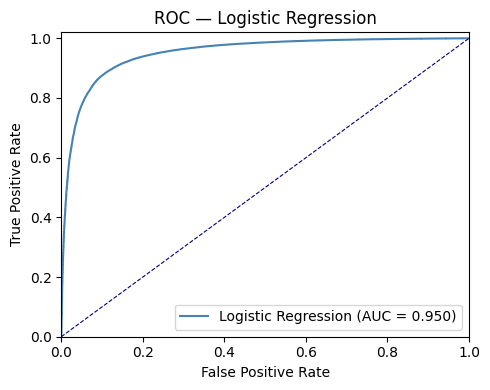

In [24]:
# Train on the precomputed features (same hyperparameters as Section 6)
lr_for_comparison = LogisticRegression(
    featuresCol     = "features",
    labelCol        = "label",
    weightCol       = "classWeight",
    maxIter         = 20,
    regParam        = best_lr.getRegParam(),
    elasticNetParam = best_lr.getElasticNetParam(),
)
lr_fitted = lr_for_comparison.fit(train_features)
fpr_lr, tpr_lr, auc_lr = evaluate_model("Logistic Regression", lr_fitted, test_features, colour="steelblue")

### 7.2 Naive Bayes

The textbook text-classification model. Fast to train, assumes feature independence
(a strong assumption that turns out to work surprisingly well for bag-of-words).

Note: Spark's Naive Bayes doesn't accept negative feature values. TF-IDF is always
non-negative, so we're fine. Also, NB doesn't support `weightCol`, so this one runs
without class weights.

=== Naive Bayes ===
  AUC-ROC: 0.5729
  Class 0 (neg): precision=0.5928  recall=0.8126
  Class 1 (pos): precision=0.9593  recall=0.8880


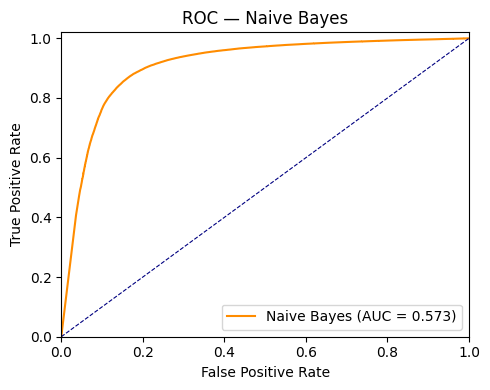

In [25]:
nb = NaiveBayes(
    featuresCol = "features",
    labelCol    = "label",
    smoothing   = 1.0,                  # Laplace smoothing (standard)
    modelType   = "multinomial",        # right choice for TF/TF-IDF features
)
nb_fitted = nb.fit(train_features)
fpr_nb, tpr_nb, auc_nb = evaluate_model("Naive Bayes", nb_fitted, test_features, colour="darkorange")

### 7.3 LinearSVC

A large-margin linear classifier. Often slightly better than LR on text. Supports
`weightCol` so we get the class-weighting benefit.

LinearSVC outputs raw scores rather than calibrated probabilities, so the ROC curve
uses `rawPrediction` instead of `probability`. We handle this with a small inline
version of the helper.

=== LinearSVC ===
  AUC-ROC: 0.9361
  Class 0 (neg): precision=0.7000  recall=0.8130
  Class 1 (pos): precision=0.9612  recall=0.9301


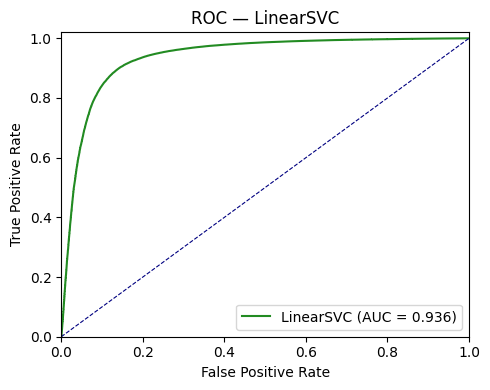

In [26]:
svc = LinearSVC(
    featuresCol = "features",
    labelCol    = "label",
    weightCol   = "classWeight",
    maxIter     = 20,
    regParam    = 0.01,
)
svc_fitted = svc.fit(train_features)

# Custom evaluation because LinearSVC has no `probability` column
svc_preds = svc_fitted.transform(test_features)
auc_svc = auc_evaluator.evaluate(svc_preds)
pcm_svc = per_class_metrics(svc_preds)

print(f"=== LinearSVC ===")
print(f"  AUC-ROC: {auc_svc:.4f}")
for cls in [0, 1]:
    name = "neg" if cls == 0 else "pos"
    print(f"  Class {cls} ({name}): precision={pcm_svc[cls]['precision']:.4f}  "
          f"recall={pcm_svc[cls]['recall']:.4f}")

# ROC from rawPrediction (LinearSVC's score column)
rows = svc_preds.select("rawPrediction", "label").collect()
scores = [float(r["rawPrediction"][1]) for r in rows]
labels = [r["label"] for r in rows]
fpr_svc, tpr_svc, _ = roc_curve(labels, scores)

plt.figure(figsize=(5, 4))
plt.plot(fpr_svc, tpr_svc, color="forestgreen", label=f"LinearSVC (AUC = {auc_svc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", linestyle="--", linewidth=0.8)
plt.xlim([0, 1]); plt.ylim([0, 1.02])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC — LinearSVC"); plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

results.append(("LinearSVC", round(auc_svc, 4),
                round(pcm_svc[0]['recall'], 4),
                round(pcm_svc[1]['recall'], 4)))

### 7.4 Combined ROC plot and ranking table

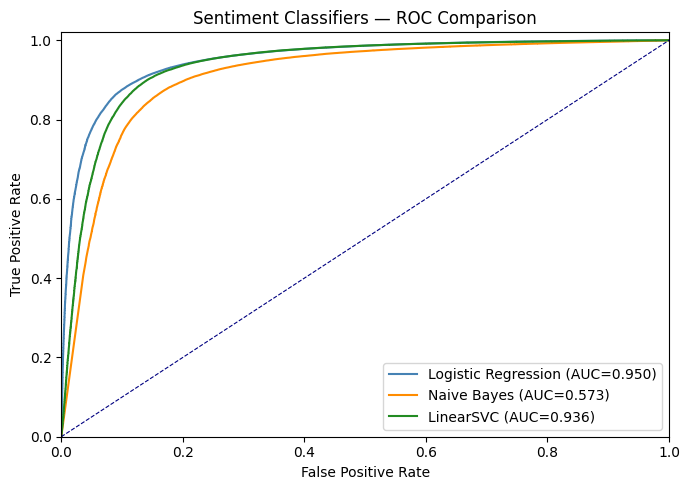

In [27]:
# All three on one plot
plt.figure(figsize=(7, 5))
plt.plot(fpr_lr,  tpr_lr,  color="steelblue",   label=f"Logistic Regression (AUC={auc_lr:.3f})")
plt.plot(fpr_nb,  tpr_nb,  color="darkorange",  label=f"Naive Bayes (AUC={auc_nb:.3f})")
plt.plot(fpr_svc, tpr_svc, color="forestgreen", label=f"LinearSVC (AUC={auc_svc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", linestyle="--", linewidth=0.8)
plt.xlim([0, 1]); plt.ylim([0, 1.02])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Sentiment Classifiers — ROC Comparison")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

In [28]:
# Ranking table
summary_df = spark.createDataFrame(
    results,
    ["Model", "AUC_ROC", "Recall_Negative", "Recall_Positive"]
).orderBy(F.desc("AUC_ROC"))
summary_df.show(truncate=False)

+-------------------+-------+---------------+---------------+
|Model              |AUC_ROC|Recall_Negative|Recall_Positive|
+-------------------+-------+---------------+---------------+
|Logistic Regression|0.9503 |0.8618         |0.9081         |
|LinearSVC          |0.9361 |0.813          |0.9301         |
|Naive Bayes        |0.5729 |0.8126         |0.888          |
+-------------------+-------+---------------+---------------+



---
## 8. Interpreting the LR Model — Top Sentiment Words

A nice perk of CountVectorizer + LogisticRegression: we can pair LR's coefficients with
the learned vocabulary to see which words push toward "negative" and which toward
"positive".

Great material for the management presentation — concrete and intuitive.

In [29]:
# Extract the CountVectorizer and LR from the final pipeline
# (stages: [tokenizer, stopwords_remover, count_vectorizer, idf, lr])
cv_model_stage = final_model.stages[2]
lr_model_stage = final_model.stages[-1]

vocabulary   = cv_model_stage.vocabulary           # list of words
coefficients = lr_model_stage.coefficients.toArray()  # one weight per word

# Pair them up. Positive coefficient -> pushes prediction toward class 1 (positive)
word_coef = list(zip(vocabulary, coefficients))

# Top words pushing toward POSITIVE sentiment
top_positive = sorted(word_coef, key=lambda x: x[1], reverse=True)[:20]
# Top words pushing toward NEGATIVE sentiment
top_negative = sorted(word_coef, key=lambda x: x[1])[:20]

print("Top 20 words signalling POSITIVE sentiment:")
for word, coef in top_positive:
    print(f"  {word:<25}  {coef:+.4f}")

print("\nTop 20 words signalling NEGATIVE sentiment:")
for word, coef in top_negative:
    print(f"  {word:<25}  {coef:+.4f}")

Top 20 words signalling POSITIVE sentiment:
  great                      +0.8289
  best                       +0.5420
  delicious                  +0.4845
  excellent                  +0.4352
  perfect                    +0.3702
  loves                      +0.3500
  good                       +0.3203
  wonderful                  +0.3188
  yummy                      +0.3163
  love                       +0.3071
  awesome                    +0.2512
  favorite                   +0.2331
  amazing                    +0.2230
  pleasantly                 +0.2211
  highly                     +0.2200
  yum                        +0.2173
  tasty                      +0.2101
  nice                       +0.2088
  fantastic                  +0.1967
  addictive                  +0.1949

Top 20 words signalling NEGATIVE sentiment:
  disappointing              -0.3058
  disappointed               -0.3033
  worst                      -0.2982
  disappointment             -0.2408
  terrible             

In [30]:
# Horizontal bar chart for the presentation
import plotly.graph_objs as go

labels  = [w for w, _ in top_negative[::-1]] + [w for w, _ in top_positive]
values  = [c for _, c in top_negative[::-1]] + [c for _, c in top_positive]
colours = ["crimson"] * 20 + ["seagreen"] * 20

fig = go.Figure(go.Bar(
    x = values,
    y = labels,
    orientation = "h",
    marker = dict(color=colours),
))
fig.update_layout(
    title  = "Most influential words for sentiment classification",
    xaxis_title = "LR coefficient (negative ← → positive)",
    height = 800,
)
fig.show()

---
## 9. Saving and Reloading the Pipeline

A fitted `PipelineModel` saves to disk in a single call. The saved version includes
the CountVectorizer vocabulary, the IDF weights, and the LR coefficients — everything
needed to score new data. Loading is symmetric.

This is the "productionization handoff": one notebook trains and saves, another
loads and applies (e.g. the Streaming notebook).

In [31]:
MODEL_PATH = f"{PROJECT_DIR}/sentiment_pipeline_model"

# Save (overwrite if it already exists)
final_model.write().overwrite().save(MODEL_PATH)
print(f"Pipeline saved to {MODEL_PATH}")

# Reload and check we get identical predictions
loaded_model = PipelineModel.load(MODEL_PATH)
loaded_predictions = loaded_model.transform(test_df)
auc_loaded = auc_evaluator.evaluate(loaded_predictions)

print(f"AUC from re-loaded pipeline: {auc_loaded:.4f}")
print(f"AUC from in-memory pipeline: {auc_final:.4f}")
assert abs(auc_loaded - auc_final) < 1e-6, "Loaded model should match original!"
print("Loaded model produces identical predictions.")

Pipeline saved to /content/drive/MyDrive/Colab Notebooks/sentiment_pipeline_model
AUC from re-loaded pipeline: 0.9503
AUC from in-memory pipeline: 0.9503
Loaded model produces identical predictions.


---
## 10. Helpfulness Prediction — A Second Model

Helpfulness is more analytically interesting than sentiment because the label isn't
trivially encoded in the input. We're asking: can we predict, from a review's content
and metadata, whether other customers will find it useful?

### 10.1 The helpfulness label

A review is "helpful" if:
- At least 5 people voted on its helpfulness (so we have real signal — not just one
  person's opinion)
- AND more than 60% of voters found it helpful

Reviews with fewer than 5 votes are dropped — we genuinely don't know if they're
helpful. This shrinks the dataset (most reviews have zero votes), but the remaining
reviews have reliable labels.

In [32]:
MIN_VOTES = 5
HELPFUL_THRESHOLD = 0.6

helpfulness_df = (
    reviews_df
        .filter(col("HelpfulnessDenominator") >= MIN_VOTES)
        .withColumn(
            "helpful_label",
            F.when(col("HelpfulnessRatio") > HELPFUL_THRESHOLD, 1).otherwise(0)
        )
        .withColumn(
            "fullText",
            F.concat_ws(" ", F.coalesce(col("Summary"), F.lit("")), col("Text"))
        )
        # Engineered features — emotional intensity proxies
        .withColumn("exclamation_count", F.length(col("Text")) - F.length(F.regexp_replace(col("Text"), "!", "")))
        .withColumn("question_count",    F.length(col("Text")) - F.length(F.regexp_replace(col("Text"), r"\?", "")))
        # Average word length as a proxy for vocabulary richness
        .withColumn("avg_word_length",
                    F.when(col("WordCount") > 0,
                           col("TextLength") / col("WordCount")).otherwise(0.0))
        .select(
            "Id", "ReviewDate", "helpful_label", "fullText",
            "Score", "TextLength", "WordCount",
            "exclamation_count", "question_count", "avg_word_length",
            "HelpfulnessDenominator",
        )
)

print(f"Helpfulness dataset size: {helpfulness_df.count():,}")
print("\nLabel distribution:")
helpfulness_df.groupBy("helpful_label").count().orderBy("helpful_label").show()

Helpfulness dataset size: 47,712

Label distribution:
+-------------+-----+
|helpful_label|count|
+-------------+-----+
|            0|11694|
|            1|36018|
+-------------+-----+



### 10.2 Class weights and temporal split (same as before)

In [33]:
# Class weights
help_counts = {
    row["helpful_label"]: row["count"]
    for row in helpfulness_df.groupBy("helpful_label").count().collect()
}
help_total = sum(help_counts.values())

help_w_pos = help_total / (2 * help_counts[1])
help_w_neg = help_total / (2 * help_counts[0])

helpfulness_df = helpfulness_df.withColumn(
    "classWeight",
    F.when(col("helpful_label") == 1, F.lit(help_w_pos)).otherwise(F.lit(help_w_neg))
)

# Temporal split — same cutoff as before
help_train = helpfulness_df.filter(F.year("ReviewDate") <  TEMPORAL_CUTOFF_YEAR).cache()
help_test  = helpfulness_df.filter(F.year("ReviewDate") >= TEMPORAL_CUTOFF_YEAR).cache()
print(f"Helpfulness train: {help_train.count():,}   test: {help_test.count():,}")

Helpfulness train: 21,522   test: 26,190


### 10.3 The helpfulness pipeline

This pipeline is richer than the sentiment one. It combines:
- **Word2Vec embeddings** of the review text (tokenize → Word2Vec → PCA)
- **Structured features**: text length, word count, exclamation count, etc.
- **Scaling**: `MinMaxScaler` so structured features don't get dominated by the PCA components

### Why Word2Vec + PCA instead of TF-IDF here?
For helpfulness, the *semantic richness* of the text matters more than the presence
of specific words. Word2Vec captures semantic similarity — reviews using different
vocabulary but discussing similar topics end up close in embedding space. PCA then
shrinks the 100-dim embedding to 20 dimensions, comparable in size to the structured
features so neither block dominates.

In [34]:
# --- Text pipeline stages ---
help_tokenizer = RegexTokenizer(
    inputCol="fullText", outputCol="tokens",
    pattern=r"\W+", toLowercase=True, minTokenLength=2,
)
help_stopwords = StopWordsRemover(inputCol="tokens", outputCol="tokens_clean")

# Word2Vec — same settings as in the practical classes
word2vec = Word2Vec(
    inputCol   = "tokens_clean",
    outputCol  = "text_embedding",
    vectorSize = 100,
    minCount   = 5,
    seed       = 42,
)

# PCA to reduce 100 dims to 20
pca = PCA(k=20, inputCol="text_embedding", outputCol="text_pca")

# --- Structured-feature stages ---
NUMERIC_FEATURES = [
    "Score", "TextLength", "WordCount",
    "exclamation_count", "question_count", "avg_word_length",
]
numeric_assembler = VectorAssembler(
    inputCols = NUMERIC_FEATURES,
    outputCol = "numeric_raw",
)
numeric_scaler = MinMaxScaler(
    inputCol  = "numeric_raw",
    outputCol = "numeric_scaled",
)

# Final assembly — combine the scaled numeric block with the PCA'd text block
final_assembler = VectorAssembler(
    inputCols = ["numeric_scaled", "text_pca"],
    outputCol = "features",
)

# Classifier — Random Forest
rf_helpful = RandomForestClassifier(
    featuresCol = "features",
    labelCol    = "helpful_label",
    numTrees    = 100,
    maxDepth    = 8,
    seed        = 42,
)

help_pipeline = Pipeline(stages=[
    help_tokenizer, help_stopwords, word2vec, pca,
    numeric_assembler, numeric_scaler, final_assembler,
    rf_helpful,
])

print("Helpfulness pipeline assembled with", len(help_pipeline.getStages()), "stages.")

Helpfulness pipeline assembled with 8 stages.


In [35]:
t0 = time.time()
help_model = help_pipeline.fit(help_train)
print(f"Helpfulness pipeline fitted in {time.time() - t0:.1f}s")

Helpfulness pipeline fitted in 107.4s


In [36]:
# Evaluate on the test set
help_evaluator = BinaryClassificationEvaluator(
    labelCol         = "helpful_label",
    rawPredictionCol = "rawPrediction",
    metricName       = "areaUnderROC",
)

help_predictions = help_model.transform(help_test).cache()
auc_help = help_evaluator.evaluate(help_predictions)
print(f"Helpfulness RF — Test AUC-ROC: {auc_help:.4f}")

print("\nConfusion matrix:")
help_predictions.groupBy("helpful_label").pivot("prediction").count().orderBy("helpful_label").show()

# Per-class metrics
help_pcm = per_class_metrics(help_predictions, label_col="helpful_label")
print("\nPer-class metrics:")
for cls in [0, 1]:
    name = "not-helpful" if cls == 0 else "helpful"
    print(f"  Class {cls} ({name}): precision={help_pcm[cls]['precision']:.4f}  "
          f"recall={help_pcm[cls]['recall']:.4f}")

Helpfulness RF — Test AUC-ROC: 0.8122

Confusion matrix:
+-------------+----+-----+
|helpful_label| 0.0|  1.0|
+-------------+----+-----+
|            0|2726| 4573|
|            1|1606|17285|
+-------------+----+-----+


Per-class metrics:
  Class 0 (not-helpful): precision=0.6293  recall=0.3735
  Class 1 (helpful): precision=0.7908  recall=0.9150


### 10.4 Feature importances

Random Forest exposes `featureImportances` — how much each feature contributes to the
model's decisions. This tells us what makes a review helpful.

In [37]:
rf_model = help_model.stages[-1]
importances = rf_model.featureImportances.toArray()

# Feature vector layout: [numeric_scaled (6)] + [text_pca (20)]
feature_names = NUMERIC_FEATURES + [f"text_pca_{i}" for i in range(20)]

# Pair, sort, show top
imp_pairs = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)
print("Feature importances (top 15):")
for name, imp in imp_pairs[:15]:
    bar = "█" * int(imp * 200)
    print(f"  {name:<22}  {imp:.4f}  {bar}")

Feature importances (top 15):
  Score                   0.5318  ██████████████████████████████████████████████████████████████████████████████████████████████████████████
  TextLength              0.0526  ██████████
  WordCount               0.0516  ██████████
  text_pca_0              0.0392  ███████
  text_pca_5              0.0332  ██████
  text_pca_8              0.0316  ██████
  text_pca_12             0.0227  ████
  text_pca_11             0.0208  ████
  text_pca_14             0.0174  ███
  text_pca_3              0.0150  ██
  text_pca_10             0.0149  ██
  avg_word_length         0.0134  ██
  text_pca_4              0.0133  ██
  text_pca_18             0.0127  ██
  text_pca_2              0.0124  ██


**What we expect**: structured features like `TextLength`, `WordCount`, and `Score`
tend to dominate over individual PCA components. The *length and shape* of a review is
a stronger signal of helpfulness than its exact semantic content. Nice line for the
presentation: *"Longer, more detailed reviews tend to be voted helpful, regardless of topic."*

---
## 11. Wrap-Up

In this notebook we built two production-style ML Pipelines.

### What we built
1. **Sentiment classifier** — LR + TF-IDF, class-weighted. AUC ≈ 0.94 on held-out future reviews.
2. **Helpfulness classifier** — Random Forest + Word2Vec embeddings + structured features.

### Spark functionalities demonstrated
- **`Pipeline`** with multiple stages
- Estimator vs Transformer distinction (`fit` produces a `PipelineModel`)
- **`CrossValidator`** + **`ParamGridBuilder`** for hyperparameter tuning
- **`Word2Vec`** for distributed text embeddings
- **`PCA`** for dimensionality reduction
- **`MinMaxScaler`** for feature scaling
- Multiple classifiers compared: LogisticRegression, NaiveBayes, LinearSVC, RandomForest
- PipelineModel save/load

### Big-data-safe practices
- Pipelines bundle preprocessing with the model — no risk of train/serve skew
- CrossValidator on a sample, final fit on the full data
- Caching only after filtering, with `.unpersist()` at the end
- Feature precomputation when comparing models
- ROC plots use sklearn on small collected arrays (bounded by # of thresholds, not data size)

### Decisions we made (ready to defend in the interview)
- Sentiment uses text-only features to avoid leaking the score
- Temporal train/test split simulates real production deployment
- Class weights trade some positive-class precision for negative-class recall — the right trade-off for "flag negative reviews"
- CountVectorizer (not HashingTF) for interpretability; at scale we'd switch

### Next notebooks
- **Notebook 3**: DistilBERT sentiment via `predict_batch_udf` — and using those predictions as an input feature for a second-pass model


In [38]:
# Cleanup
for df in [train_df, test_df, train_features, test_features,
           final_predictions, help_train, help_test, help_predictions]:
    try:
        df.unpersist()
    except Exception:
        pass

spark.stop()
print("Spark session stopped.")

Spark session stopped.
